# Q16. Does a larger continuation improve the successful Evo2 adapter?

Continue the [Q14 winner](Q14-layer-adapters.ipynb) on **all 46,888 training variants**, for at most **three additional epochs**. This is a single registered learning-rate run. Its **four-hour cumulative budget includes preparation, training, full validation, checkpoint verification and reporting**. A measured validation reserve stops training early if needed. Historical model acquisition and Q12/Q14 fitting are prerequisites.

Use **Lida** on the prepared H100 80 GB and run all cells in order. [Frozen protocol](src/q16.py) · [GPU workflow](src/q16_backend.py) · [Reporting](src/q16_report.py) · [Setup](../README.md#setup).

In [1]:
from src import q16, q16_report

## Freeze inputs and the cumulative deadline

Reuse the checksum-pinned **6 July 2026 ClinVar, GRCh38, missense SNV** cohort. Keep all **46,888 training** and **17,927 validation** variants in their inherited gene/component/locus/sequence-disjoint partitions. Recheck eligibility, VCF checksums, labels and canonical 512-base allele-context separation. Validation is development data; `clinvar-test.vcf` does not denote an untouched test set.

Retain Q14’s exact **2,048 validation keys** for checkpoint selection. Full validation does not select a checkpoint or refit parameters. Sources, parent checkpoints, exact memberships and the original request deadline are frozen before training. Resumption preserves that deadline. No validation labels enter gradients or preprocessing.

In [2]:
protocol = q16.prepare()

Frozen all 46,888 training variants, the existing 2,048 selection variants, and all 17,927 full-validation variants.


## Continue the adapter, then validate all three models

Load Q14’s selected nonzero adapters in **blocks 29 and 30**, rank **8**, alpha **16**, dropout **0**. Keep the original 7B backbone, **8,195-parameter classifier** and training-fitted scaler fixed. The 8,194 features retain reference/difference direction and mutation magnitude. Only **393,216 adapter parameters** update.

Warm restart **AdamW** with fresh optimizer state and FP32 masters initialized from the saved BF16 adapters. Use peak learning rate **3e-5**, **64-step warmup**, cosine decay to 10%, weight decay **0.01**, gradient norm limit **1**, seed **42**, and batch **32 variants**. Shuffle all training variants independently each epoch and retain the final eight-variant batch: at most **4,398 updates / 140,664 examples**. Balanced BCE weights are computed from the full training labels.

Compute actual Q14 starting predictions, monitor every **512 updates** and at stopping, and save optimizer/master/RNG/cursor state every **32 updates**. Keep the best newly trained checkpoint by sampled AUROC, then AP. Retain it only if AUROC strictly improves over Q14 without an AP decrease; otherwise retain Q14. Preserve the best continuation even when it loses.

Reserve at least **65 minutes plus reporting time**, adjusted upward by measured inference speed. Run fresh full inference for the best continuation, Q14 parent, and original frozen control regardless of the selection outcome. Destroy and reload learned tensors to verify 64 predictions, reproduce inherited predictions, and verify unchanged backbone, classifier and scaler.

The first preflight stopped before training because **batch-one BF16 scoring** differed from batched scoring; its real failed notebook and sources are archived. The revised preflight measures that sensitivity and enforces the original **2e-4** tolerance on operational batch comparisons, permutations, repeatability and reverse complements. Single-variant numerical equivalence is not claimed.

In [3]:
result = q16.run_experiment()

Continuation and full validation: notebooks/results/q16/run.log


## Full development results and uncertainty

Report AUROC/AP with **1,000 whole-component bootstrap resamples**, seed **42**, and paired continuation-minus-Q14 and continuation-minus-frozen effects. Also show the **15,879 variants outside selection** and **3,246 variants in components absent from selection**. Neither subset is an untouched holdout, and intervals do not correct repeated model selection. Pretraining exposure, homology and shared-patient overlap remain unresolved. Preserve negative results and actual timing.

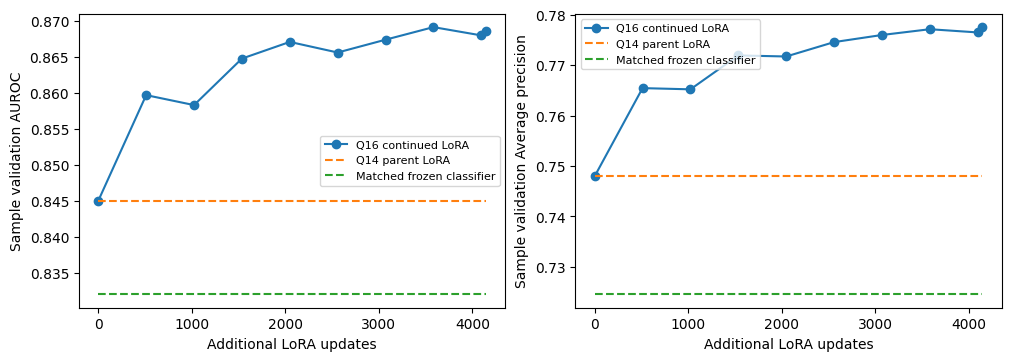

**Full validation: 17,927 variants**

| Model | AUROC [95% CI] | Average precision [95% CI] |
| --- | ---: | ---: |
| Q16 continued LoRA | 0.872 [0.859, 0.884] | 0.801 [0.769, 0.828] |
| Q14 parent LoRA | 0.852 [0.838, 0.865] | 0.770 [0.736, 0.797] |
| Matched frozen classifier | 0.839 [0.824, 0.852] | 0.749 [0.716, 0.778] |

<details><summary>Checkpoint-selection sample</summary>

| Model | AUROC [95% CI] | Average precision [95% CI] |
| --- | ---: | ---: |
| Q16 continued LoRA | 0.869 | 0.777 |
| Q14 parent LoRA | 0.845 | 0.748 |
| Matched frozen classifier | 0.832 | 0.725 |

</details>

Continuation minus Q14 parent LoRA: AUROC **+0.0204 [+0.0160, +0.0249]**, AP **+0.0316 [+0.0250, +0.0384]**.

Continuation minus frozen classifier: AUROC **+0.0335 [+0.0256, +0.0412]**, AP **+0.0522 [+0.0415, +0.0646]**.

Outside the selection sample (15,879 variants): continuation minus Q14 AUROC **+0.0199 [+0.0152, +0.0249]**, AP **+0.0320 [+0.0249, +0.0394]**.

Components absent from the selection sample (3,246 variants): continuation minus Q14 AUROC **+0.0174 [+0.0106, +0.0249]**, AP **+0.0417 [+0.0205, +0.0642]**.

In [4]:
q16_report.show_results()

## Conclusion

The conclusion below uses the complete predictions and states whether continuation improved on Q14. After this notebook finishes and is saved with all outputs, its verified result is added to the README beside the existing comparisons.

In [5]:
q16_report.show_conclusion()

**Conclusion.** The tested continuation improved full-validation AUROC without reducing AP versus Q14. Continuation minus Q14: AUROC **+0.0204 [+0.0160, +0.0249]**, AP **+0.0316 [+0.0250, +0.0384]**. The sample-based decision retains **Q16 continued LoRA**. The best nonzero-update continuation is chosen by sample AUROC, then AP; it replaces Q14 only if sample AUROC strictly increases and AP does not decrease. Full results do not change that decision. The 2,048-variant sample selects checkpoints; full validation reports the frozen selection. The full partition and its subsets have been evaluated before and are development data, not an untouched test set. Component-bootstrap intervals do not correct repeated selection or establish clinical validity. Pretraining, homology and external-data overlap remain unresolved. Single-variant BF16 scoring is numerically sensitive; Q16 uses its verified batch-32 workflow.